## Seasonal Analysis

#### Download necessary modules

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

Data you need to run this code:

                                animal_kingdom_df1(touringplans_2018).csv

                                animal_kingdom_ride_attributes.csv

                                df2_2018(clean_parks_metadate).csv

#### Predicting hourly demand based on 2018 data

In [26]:
# Load cleaned data (2018)
rideData2018 = pd.read_csv("../data/cleanData/df2_2018(clean_parks_metadate).csv")
rideData2018.head()

,date,wdw_ticket_season,dayofweek,dayofyear,weekofyear,monthofyear,year,season,holiday,wdwticketseason,...,hsfirewks,akprdday,akprddt1,akprddt2,akprddn,akfiren,akshwngt,akshwnt1,akshwnt2,akshwnn
0,2018-01-01,peak,2,0,0,1,2018,CHRISTMAS PEAK,1,peak,...,1,0,NaN,NaN,NaN,NaN,2,66600.0,71100.0,Rivers of Light
1,2018-01-02,peak,3,1,0,1,2018,CHRISTMAS,0,peak,...,1,0,NaN,NaN,NaN,NaN,2,66600.0,71100.0,Rivers of Light
2,2018-01-03,peak,4,2,0,1,2018,CHRISTMAS,0,peak,...,1,0,NaN,NaN,NaN,NaN,2,66600.0,71100.0,Rivers of Light
3,2018-01-04,regular,5,3,0,1,2018,CHRISTMAS,0,regular,...,1,0,NaN,NaN,NaN,NaN,2,66600.0,71100.0,Rivers of Light
4,2018-01-05,regular,6,4,0,1,2018,CHRISTMAS,0,regular,...,1,0,NaN,NaN,NaN,NaN,2,66600.0,71100.0,Rivers of Light


In [27]:
# Load waiting times data
waitTimes = pd.read_csv("../data/cleanData/animal_kingdom_df1(touringplans_2018).csv")
waitTimes.head()

,park_date,wait_hour,attraction_name,wait_minutes_posted_avg,attraction_duration,attraction_park,attraction_land,park_open,park_close,park_extra_magic_morning,park_extra_magic_evening,park_ticket_season,park_temperature_average,park_temperature_high,attraction_short_name
0,2018-01-01,8,DINOSAUR,15.000000,3.5,Disney's Animal Kingdom,DinoLand U.S.A.,8:00:00,20:00:00,0,0,peak,50.56,58.63,DINOSAUR
1,2018-01-01,9,DINOSAUR,18.333333,3.5,Disney's Animal Kingdom,DinoLand U.S.A.,8:00:00,20:00:00,0,0,peak,50.56,58.63,DINOSAUR
2,2018-01-01,10,DINOSAUR,23.750000,3.5,Disney's Animal Kingdom,DinoLand U.S.A.,8:00:00,20:00:00,0,0,peak,50.56,58.63,DINOSAUR
3,2018-01-01,11,DINOSAUR,24.000000,3.5,Disney's Animal Kingdom,DinoLand U.S.A.,8:00:00,20:00:00,0,0,peak,50.56,58.63,DINOSAUR
4,2018-01-01,12,DINOSAUR,31.875000,3.5,Disney's Animal Kingdom,DinoLand U.S.A.,8:00:00,20:00:00,0,0,peak,50.56,58.63,DINOSAUR


In [28]:
# Fun Factor
# Fun factor "a" calculation
a_dict = {'Kanika': {'Speed': 6, 'Music': 7, 'Show': 2, 'Light': 5, 'Water': 8, '3D': 10},
          'Lydia': {'Speed': 6, 'Music': 3, 'Show': 1, 'Light': 7, 'Water': 1, '3D': 3},
          'Shawn': {'Speed': 10, 'Music': 0, 'Show': 0, 'Light': 0, 'Water': 3, '3D': 2},
          'Clarice': {'Speed': 4, 'Music': 5, 'Show': 3, 'Light': 2, 'Water': 3, '3D': 5},
          'Ethan': {'Speed': 5, 'Music': 6, 'Show': 2, 'Light': 1, 'Water': 4, '3D': 6},
          'Kevin': {'Speed': 6, 'Music': 7, 'Show': 1, 'Light': 0, 'Water': 5, '3D': 7},
          'Allison': {'Speed': 7, 'Music': 8, 'Show': 0, 'Light': 1, 'Water': 6, '3D': 8}}

# Load attributes of rides
rideAttributes = pd.read_csv("../data/cleanData/animal_kingdom_ride_attributes.csv")

# Fun factor calculation
def calculate_fun_factor(person):
    ride_fun_factors = {}
    for ride in rideAttributes['Ride']:
        fun_factor = 0
        attributes = rideAttributes[rideAttributes['Ride'] == ride].iloc[0]
        fun_factor += (a_dict[person]['Speed'] * attributes['Speed'] +
                       a_dict[person]['Music'] * attributes['Music'] +
                       a_dict[person]['Show'] * attributes['Show'] +
                       a_dict[person]['Light'] * attributes['Light'] +
                       a_dict[person]['Water'] * attributes['Water'] +
                       a_dict[person]['3D'] * attributes['3D'])
        ride_fun_factors[ride] = float(fun_factor)
    return ride_fun_factors

In [29]:
calculate_fun_factor('Kanika')

{'DINOSAUR': 54.0,
 'Expedition Everest - Legend of the Forbidden Mountain': 57.0,
 'Avatar Flight of Passage': 100.0,
 'Kilimanjaro Safaris': 50.0,
 "Na'vi River Journey": 82.0}

In [30]:
# Create average wait time per attraction
average_wait_times = waitTimes.groupby(['wait_hour', 'attraction_name'])['wait_minutes_posted_avg'].mean().reset_index()
average_wait_times.columns = ['wait_hour', 'attraction_name', 'average_wait_time']
average_wait_times.head()

,wait_hour,attraction_name,average_wait_time
0,4,DINOSAUR,5.000000
1,4,Kilimanjaro Safaris,31.000000
2,5,Kilimanjaro Safaris,51.000000
3,6,Avatar Flight of Passage,65.803571
4,6,DINOSAUR,5.000000


In [31]:
# Attraction Duration for each ride
attraction_durations = waitTimes[['attraction_name', 'attraction_duration']].rename(columns={'attraction_name': 'Ride', 'attraction_duration': 'Duration'})
# Only keep unique rides
attraction_durations = attraction_durations.drop_duplicates(subset=['Ride'])
# Change Index to Ride
attraction_durations = attraction_durations.set_index('Ride')
attraction_durations.head()

,Duration
Ride,
DINOSAUR,3.5
Expedition Everest - Legend of the Forbidden Mountain,4.0
Avatar Flight of Passage,6.0
Kilimanjaro Safaris,20.0
Na'vi River Journey,5.0


In [32]:
def get_wait_time(ride, hour, average_wait_times):
    df = average_wait_times[
        (average_wait_times['attraction_name'] == ride) &
        (average_wait_times['wait_hour'] == hour)
    ]
    return float(df['average_wait_time'].iloc[0]) if not df.empty else 0.0

def build_dp(
    startTime = 8 * 60,     # 8 AM
    endTime   = 20 * 60,    # 8 PM
    alpha=0.8,
    beta=0.4,
    rideCountDecay = 0.5,
    person='Clarice',
    duration=attraction_durations,
    average_wait_times=average_wait_times,
    ):
    T = endTime - startTime  # 720 minutes total
    rides = duration.index.tolist()
    ride_durations = duration['Duration'].to_dict()
    fun_factors = calculate_fun_factor(person)

    # Initialize DP
    V = np.zeros(T+1)
    policy = [None]*(T+1)
    ride_counts = {ride: 0 for ride in rides}

    # Backward induction: from end of day → start
    for t in range(T-1, -1, -1):
        best_value = -np.inf
        best_ride = None
        for ride in rides:
            ride_time = float(ride_durations[ride])
            wait_hour = int(t/60) + 8
            wait_time_df = average_wait_times[
                (average_wait_times['attraction_name'] == ride) &
                (average_wait_times['wait_hour'] == wait_hour)
            ]
            wait_time = get_wait_time(ride, wait_hour, average_wait_times)
            # time after finishing the ride
            next_t = int(round(t + wait_time + ride_time))
            if next_t <= T:
                # calculate reward (fun factor - cost of wait time - cost of ride time + future value), bellman equation
                netFun = fun_factors[ride] * (rideCountDecay ** ride_counts[ride])
                fun_factors[ride] = fun_factors[ride] * (rideCountDecay ** ride_counts[ride])
                value = netFun - alpha*wait_time - beta*ride_time + V[next_t]
                if value > best_value:
                    best_value = value
                    best_ride = ride

        V[t] = best_value
        policy[t] = best_ride
        if best_ride is not None:
            ride_counts[best_ride] += 1

    # Recover optimal path
    path = []
    t = 0
    while t < T and policy[t] is not None:
        r = policy[t]
        wait_hour = int(t/60) + 8
        wt = get_wait_time(r, wait_hour, average_wait_times)
        t += int(ride_durations[r] + wt)
        path.append(r)

    return path, V[0]

In [33]:
print(build_dp(person ='Kanika'))
print(build_dp(person ='Clarice'))
print(build_dp(person ='Lydia'))
print(build_dp(person ='Shawn'))

(['DINOSAUR', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'Expedition Everest - Legend of the Forbidden Mountain', 'Expedition Everest - Legend of the Forbidden Mountain', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'DINOSAUR', 'DINOSAUR'], -399.7493669902675)
(['DINOSAUR', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'Expedition Everest - Legend of the Forbidden Mountain', 'Expedition Everest - Legend of the Forbidden Mountain', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'DINOSAUR', 'DINOSAUR'], -440.7493669902675)
(['DINOSAUR', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'Expedition Everest - Legend of the Forbidden Mountain', 'DINOSAUR', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'Kilimanjaro Safaris', 'Expedition Everest

### **Seasonal Analysis**

Clean and Align Date Columns

In [34]:
# Convert to datetime if not already
waitTimes['park_date'] = pd.to_datetime(waitTimes['park_date'])
rideData2018['date'] = pd.to_datetime(rideData2018['date'])


wait times dataframe will have a new column season (e.g., “CHRISTMAS PEAK”,
“SUMMER BREAK”, etc.) tied to each hourly attraction record

Merge Season Info Into waitTimes

In [35]:
waitTimes = waitTimes.merge(
    rideData2018[['date', 'season']],
    left_on='park_date',
    right_on='date',
    how='left'
)

In [36]:
waitTimes[['park_date', 'season']].head()

,park_date,season
0,2018-01-01,CHRISTMAS PEAK
1,2018-01-01,CHRISTMAS PEAK
2,2018-01-01,CHRISTMAS PEAK
3,2018-01-01,CHRISTMAS PEAK
4,2018-01-01,CHRISTMAS PEAK


Compute Average Wait Times per Season + Hour + Ride

In [37]:
seasonal_waits = (
    waitTimes.groupby(['season', 'wait_hour', 'attraction_name'])['wait_minutes_posted_avg']
    .mean()
    .reset_index()
)
seasonal_waits.columns = ['season', 'wait_hour', 'attraction_name', 'average_wait_time']


In [38]:
seasonal_waits[seasonal_waits['season'] == 'SUMMER BREAK'].head()


,season,wait_hour,attraction_name,average_wait_time
1095,SUMMER BREAK,6,Avatar Flight of Passage,60.000000
1096,SUMMER BREAK,6,DINOSAUR,5.000000
1097,SUMMER BREAK,6,Expedition Everest - Legend of the Forbidden M...,5.000000
1098,SUMMER BREAK,6,Na'vi River Journey,20.000000
1099,SUMMER BREAK,7,Avatar Flight of Passage,62.982143


Integrate Seasons Into Your DP Model

In [39]:
def run_dp_for_season(
    season,
    person='Lydia',
    startTime=8*60,
    endTime=20*60,
    alpha=0.8,
    beta=0.4,
    rideCountDecay=0.5,
    duration=attraction_durations,
    seasonal_waits=seasonal_waits
):
    # Filter for selected season
    season_waits = seasonal_waits[seasonal_waits['season'] == season]

    # Run DP model
    path, total_value = build_dp(
        startTime=startTime,
        endTime=endTime,
        alpha=alpha,
        beta=beta,
        rideCountDecay=rideCountDecay,
        person=person,
        duration=duration,
        average_wait_times=season_waits
    )

    return {
        'season': season,
        'person': person,
        'optimal_path': path,
        'total_fun_value': total_value
    }


Run Model Across All Seasons

In [40]:
seasons = rideData2018['season'].unique()

results = []
for s in seasons:
    try:
        result = run_dp_for_season(s, person='Lydia')
        results.append(result)
    except Exception as e:
        print(f"Error for {s}: {e}")


Then create a summary dataframe:

In [41]:
seasonal_results = pd.DataFrame(results)
seasonal_results.head()


,season,person,optimal_path,total_fun_value
0,CHRISTMAS PEAK,Lydia,"[DINOSAUR, Expedition Everest - Legend of the ...",-458.082517
1,CHRISTMAS,Lydia,"[Kilimanjaro Safaris, Kilimanjaro Safaris, Kil...",-459.828515
2,WINTER,Lydia,"[Kilimanjaro Safaris, Kilimanjaro Safaris, Kil...",-441.367047
3,MARTIN LUTHER KING JUNIOR DAY,Lydia,"[DINOSAUR, DINOSAUR, DINOSAUR, Expedition Ever...",-398.665432
4,MARDI GRAS,Lydia,"[Kilimanjaro Safaris, DINOSAUR, Expedition Eve...",-456.678788


Visualize Seasonal Comparison

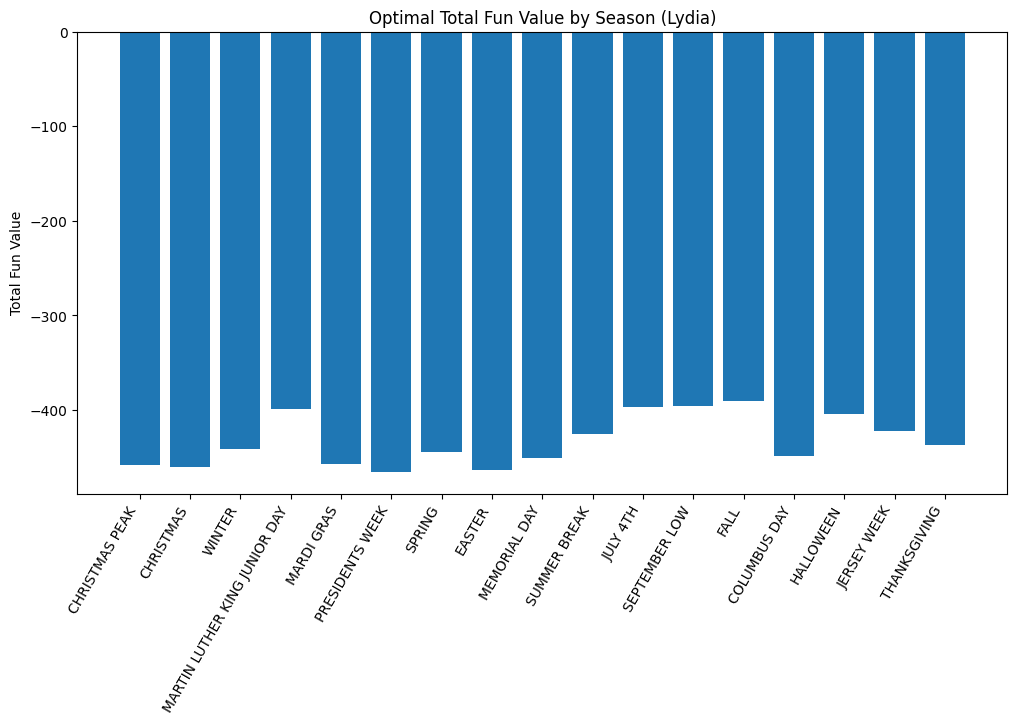

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(seasonal_results['season'], seasonal_results['total_fun_value'])
plt.xticks(rotation=60, ha='right')
plt.title("Optimal Total Fun Value by Season (Lydia)")
plt.ylabel("Total Fun Value")
plt.show()